In [1]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [2]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-




In [3]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.CAMHS`"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

CAMHS <- bq_table_download(data) 

In [4]:
head(CAMHS)

person_id,birth_datetime,ethnic_group,gender_source_value,dateevent,age_at_encounter,age_band,ctv3code,ctv3text,lsoa,partialpostcode,tbl_srpatientaddresshistory_start_date,tbl_srpatientaddresshistory_end_date,IMD,LSOA_Name,event_year
<int>,<dttm>,<chr>,<chr>,<dttm>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<int>,<chr>,<int>
25054,2004-08-15,White,Male,2019-11-05 08:32:27,15,15-20,Y070e,Child and Adolescent Mental Health Services (CAMHS,E01010779,BD18,2015-04-15,2015-04-15,3,Bradford 021C E01010779,2019
40895,1994-08-15,White,Female,2012-06-26 14:46:22,18,15-20,Y070e,Child and Adolescent Mental Health Services (CAMHS,E01010868,BD4,2020-06-11,2020-06-11,1,Bradford 061A E01010868,2012
53948,2000-09-15,White,Female,2016-03-18 09:23:52,16,15-20,Y070e,Child and Adolescent Mental Health Services (CAMHS),E01010864,SR3,2018-06-20,2018-06-20,3,Bradford 059F E01010864,2016
58485,2004-07-15,White,Female,2018-10-25 10:14:37,14,10-15,Y070e,Child and Adolescent Mental Health Services (CAMHS),E01010775,BD18,2017-11-13,2017-11-13,7,Bradford 024D E01010775,2018
62979,1997-06-15,Unknown,Female,2013-02-08 13:24:02,16,15-20,Y070e,Child and Adolescent Mental Health Services (CAMHS,E01010626,LS26,2011-06-14,2011-06-14,1,Bradford 038D E01010626,2013
65438,1999-04-15,White,Female,2014-01-24 10:33:20,15,15-20,Y070e,Child and Adolescent Mental Health Services (CAMHS,E01010708,BD20,2021-03-04,2021-03-04,5,Bradford 006C E01010708,2014


In [5]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.CAMHS`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

CAMHSAVG <- bq_table_download(data1) 

In [6]:
library(forcats)

In [7]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [8]:
CAMHS$age_band <- factor(CAMHS$age_band, levels = c("0-5", "5-10", "10-15", "15-20", "20-25", "25+"))

In [9]:
label(CAMHS$IMD)      <- "IMD"
label(CAMHS$ethnic_group)      <- "Ethnic Group"
label(CAMHS$gender_source_value)      <- "Gender"
label(CAMHS$age_band)      <- c("Age Band")

In [10]:
 x<-table1(~ CAMHS$IMD + CAMHS$ethnic_group +CAMHS$gender_source_value +CAMHS$age_band |CAMHS$event_year,data=CAMHS
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COS-EY 3: Mental Health - Child and Adolescent Mental Health Services (CAMHS):
a demographic breakdown of a Bradford Primary Care sample from Connected Bradford using ctv3 code 'Y070e'"
         )

Warning message in table1.formula(~CAMHS$IMD + CAMHS$ethnic_group + CAMHS$gender_source_value + :
“Terms to the right of '|' in formula 'x' define table columns and are expected to be factors with meaningful labels.”
Warning message in .table1.internal(x = x, labels = labels, groupspan = groupspan, :
“Table has 13 columns. Are you sure this is what you want?”


In [11]:
display_jupyter(x)

,2012(N=53),2013(N=76),2014(N=81),2015(N=91),2016(N=105),2017(N=145),2018(N=94),2019(N=85),2020(N=79),2021(N=87),2022(N=80),2023(N=17),Overall(N=993)
IMD,,,,,,,,,,,,,
Mean (SD),3.77 (2.70),2.89 (2.22),3.06 (2.53),3.31 (2.29),3.45 (2.37),2.81 (2.34),3.11 (2.43),2.42 (1.98),3.05 (2.28),3.71 (2.51),3.46 (2.59),4.18 (2.27),3.17 (2.40)
"Median [Min, Max]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","3.00 [1.00, 9.00]","1.00 [1.00, 10.0]","2.00 [1.00, 9.00]","2.00 [1.00, 9.00]","2.00 [1.00, 10.0]","3.00 [1.00, 9.00]","3.00 [1.00, 10.0]","5.00 [1.00, 8.00]","2.00 [1.00, 10.0]"
Ethnic Group,,,,,,,,,,,,,
Asian or Asian British,4 (7.5%),18 (23.7%),16 (19.8%),22 (24.2%),17 (16.2%),36 (24.8%),24 (25.5%),22 (25.9%),16 (20.3%),16 (18.4%),23 (28.8%),3 (17.6%),217 (21.9%)
Mixed multiple ethnic groups,3 (5.7%),2 (2.6%),2 (2.5%),0 (0%),2 (1.9%),2 (1.4%),4 (4.3%),0 (0%),2 (2.5%),1 (1.1%),2 (2.5%),0 (0%),20 (2.0%)
Other ethnic group,1 (1.9%),0 (0%),1 (1.2%),2 (2.2%),1 (1.0%),0 (0%),3 (3.2%),2 (2.4%),1 (1.3%),0 (0%),2 (2.5%),0 (0%),13 (1.3%)
Unknown,7 (13.2%),10 (13.2%),11 (13.6%),19 (20.9%),26 (24.8%),20 (13.8%),15 (16.0%),9 (10.6%),16 (20.3%),9 (10.3%),6 (7.5%),1 (5.9%),149 (15.0%)
White,38 (71.7%),46 (60.5%),51 (63.0%),47 (51.6%),59 (56.2%),84 (57.9%),48 (51.1%),51 (60.0%),42 (53.2%),61 (70.1%),47 (58.8%),13 (76.5%),587 (59.1%)
Black or African or Caribbean or Black British,0 (0%),0 (0%),0 (0%),1 (1.1%),0 (0%),3 (2.1%),0 (0%),1 (1.2%),2 (2.5%),0 (0%),0 (0%),0 (0%),7 (0.7%)


In [12]:
library(dplyr)

`summarise()` has grouped output by 'event_year'. You can override using the
`.groups` argument.


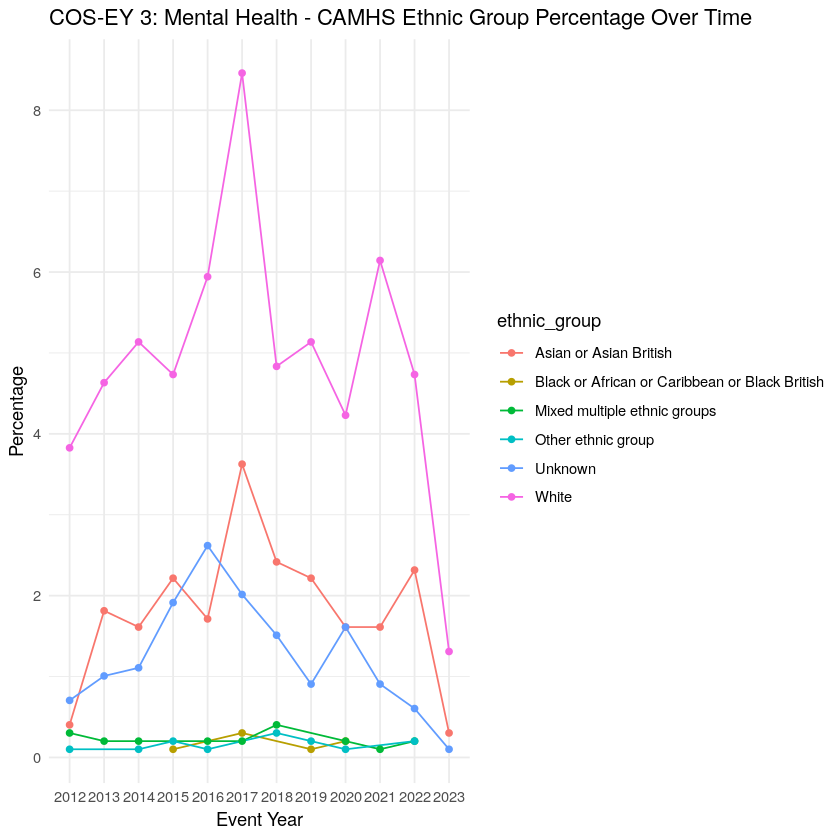

In [13]:
CAMHS_percentage <- CAMHS %>%
  group_by(event_year, ethnic_group) %>%
  summarise(percentage = n() / nrow(CAMHS) * 100)


CAMHS_percentage$event_year <- factor(CAMHS_percentage$event_year, levels = as.character(2012:2023))

ggplot(CAMHS_percentage, aes(x = event_year, y = percentage, group = ethnic_group, color = ethnic_group)) +
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 3: Mental Health - CAMHS Ethnic Group Percentage Over Time",
       x = "Event Year",
       y = "Percentage") +
  theme_minimal()

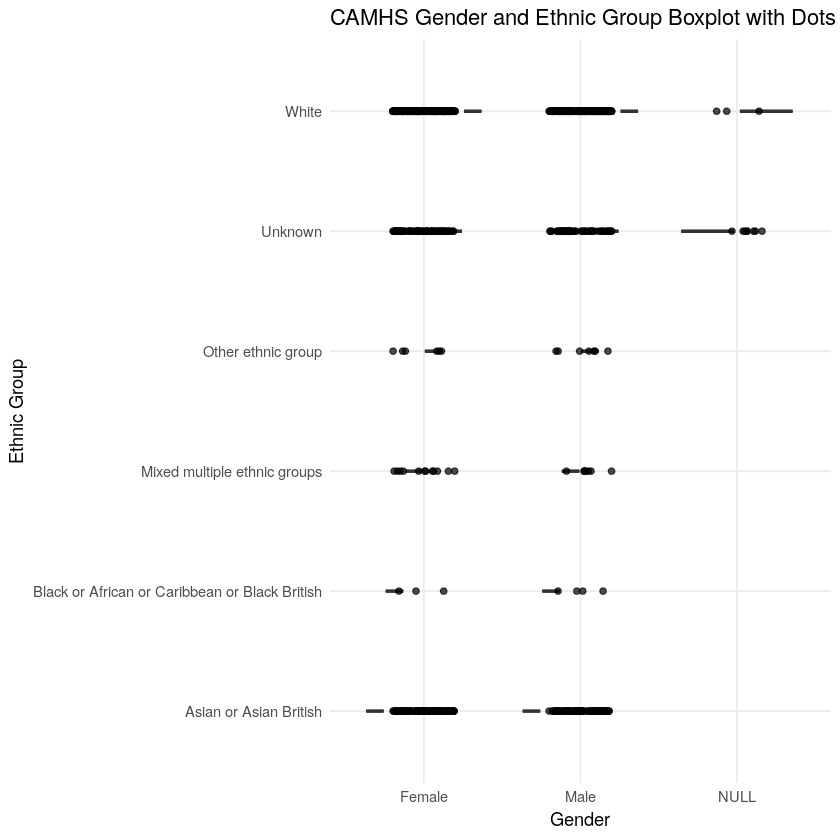

In [14]:
ggplot(CAMHS, aes(x = gender_source_value, y = ethnic_group)) +
  geom_boxplot() +
  geom_point(position = position_jitter(width = 0.2, height = 0), alpha = 0.7) +
  labs(title = "CAMHS Gender and Ethnic Group Boxplot with Dots",
       x = "Gender",
       y = "Ethnic Group") +
  theme_minimal()


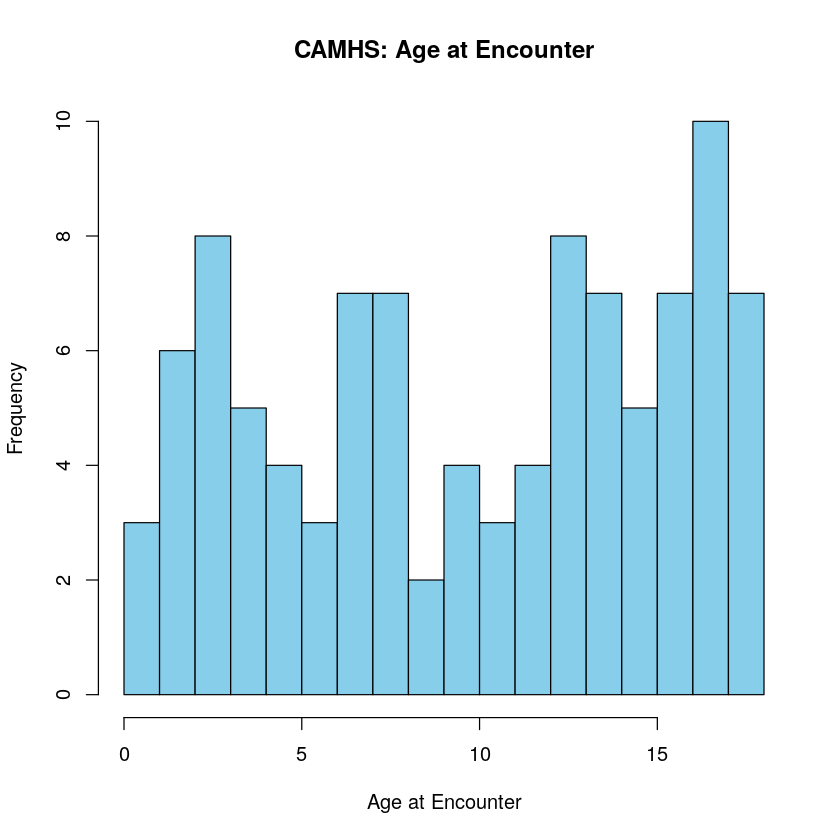

In [15]:
CAMHS <- data.frame(age_at_encounter = sample(1:18, 100, replace = TRUE))


hist(CAMHS$age_at_encounter, 
     col = "skyblue",             # Specify color
     main = "CAMHS: Age at Encounter",   # Title of the plot
     xlab = "Age at Encounter",   # X-axis label
     ylab = "Frequency",          # Y-axis label
     breaks = seq(0, max(CAMHS$age_at_encounter), by = 1))  # Specify breaks


